In [1]:
import copy
from   random import choice
import math 

import numpy as np
from   sklearn.cluster import HDBSCAN, DBSCAN
import hdbscan

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import NaiveDE
import SpatialDE
import pandas as pd

import networkx as nx

from plot import *
from data import *
from filt import *
from filt import ITNI, ITSNI, VNI

from scipy.optimize import minimize
from scipy.stats import nbinom


from matplotlib.patches import Circle
from matplotlib.lines import Line2D

import scanpy

In [32]:
#Definzione colori + funzioni per disegnare 

W  = '#efefd0'
B  = '#004e89'
Or = "#ff6b35"
mpl.rcParams['text.color']       = B
mpl.rcParams['axes.labelcolor']  = B
mpl.rcParams['axes.edgecolor']   = B
mpl.rcParams['axes.facecolor']   = W
mpl.rcParams['figure.facecolor'] = W
mpl.rcParams['xtick.color']      = B
mpl.rcParams['ytick.color']      = B
mpl.rcParams['font.family']      = "monospace"

c1 = "#35cde2"
c2 = "#ab2b2b"

colors    = [B, Or]
cmap_name = "balck_yellow"
myCMAP    = LinearSegmentedColormap.from_list(cmap_name, colors)

In [23]:
scdata = load_data()
pgdata = np.load("trasnformed_gdata.npy")
df_meta = pd.read_csv("1.DLPFC/151673/metadata.tsv", sep='\t')
coords = df_meta[['imagecol', 'imagerow']].to_numpy(np.float32)
scdata.obsm['X_spatial'] = coords


/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [24]:
index_to_cart = np.zeros((len(scdata.obs), 2))
max_row       = scdata.obs['array_row'].max()
for i, ind in enumerate(scdata.obs.index):
    col = scdata.obs['array_col'][ind]
    row = scdata.obs['array_row'][ind]
    index_to_cart[i, 0] = col             * (np.sqrt(3)/2)
    index_to_cart[i, 1] = (max_row - row) * (3/2)

/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


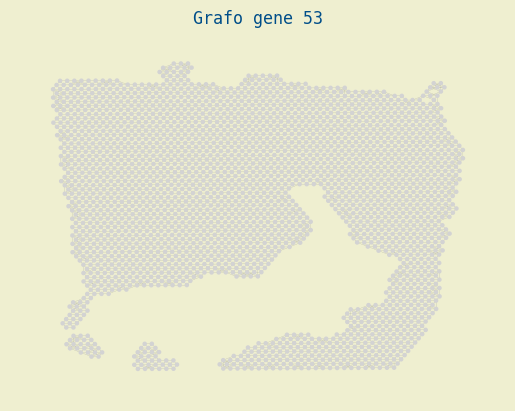

/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


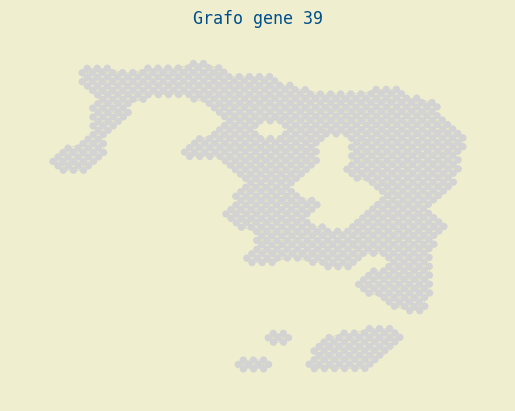

In [33]:
pgSingleData = pgdata[53]
scdata.obsm["show_gene"] = pgSingleData.reshape(-1, 1)
scdata.obsm['X_draw_graph_fr'] = index_to_cart.astype(np.float32)



def graph_for_gene(scdata, pgdata, gene_idx, k=6):
    mask = pgdata[gene_idx].astype(bool)
    ad   = scdata[mask].copy()
    if ad.n_obs < 2:
        raise ValueError("Troppi pochi spot attivi per costruire un grafo.")
    k_eff = min(k, ad.n_obs - 1)

    # 1) Grafo kNN sulle VERE coordinate
    sc.pp.neighbors(ad, n_neighbors=k_eff, use_rep='X_spatial', metric='euclidean')

    # 2) NON chiamare sc.tl.draw_graph (sposterebbe i punti).
    #    Invece, “fissa” il layout alla posizione reale:
    ad.obsm['X_draw_graph_fr'] = ad.obsm['X_spatial'].astype('float32')

    # 3) Disegna: draw_graph usa 'X_draw_graph_fr' per posizionare i nodi
    sc.pl.draw_graph(ad, layout="fr", edges=True, frameon=False, title=f"Grafo gene {gene_idx}", cmap=myCMAP)

    # Se ti serve anche A e D:
    A = ad.obsp['connectivities']; D = ad.obsp['distances']
    orig_idx = np.where(mask)[0]
    return ad, A, D, orig_idx


# Esempio per due geni
ad1, A1, D1, idx1 = graph_for_gene(scdata, pgdata, gene_idx=53, k=6)
ad2, A2, D2, idx2 = graph_for_gene(scdata, pgdata, gene_idx=39, k=6)

# Plot (facoltativo)
# sc.pl.draw_graph(ad1, frameon=False, title="Grafo gene 53 (solo spot attivi)")
# sc.pl.draw_graph(ad2, frameon=False, title="Grafo gene 39 (solo spot attivi)")



# scanpy.pp.neighbors(scdata, n_neighbors=6, use_rep="show_gene")

# scanpy.tl.draw_graph(scdata, layout="fr", random_state=42)       # o init_pos='X_spatial' se ce l’hai
# scanpy.pl.draw_graph(scdata, color="show_gene", frameon=False)
